In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Load dataset
df = pd.read_csv("../data/raw/training.csv")

print("Shape:", df.shape)

df.head()

Shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


In [4]:
df.isnull().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

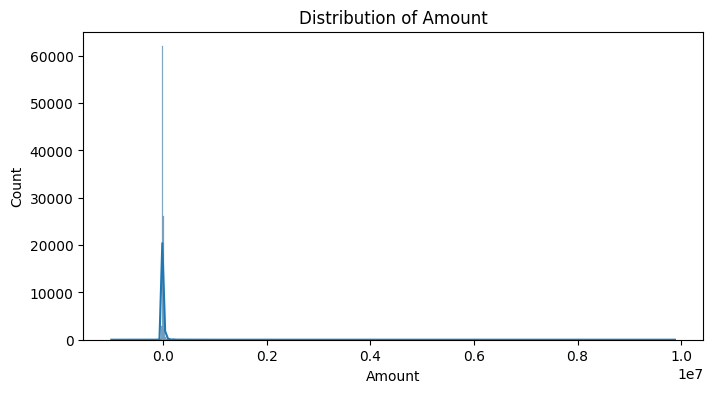

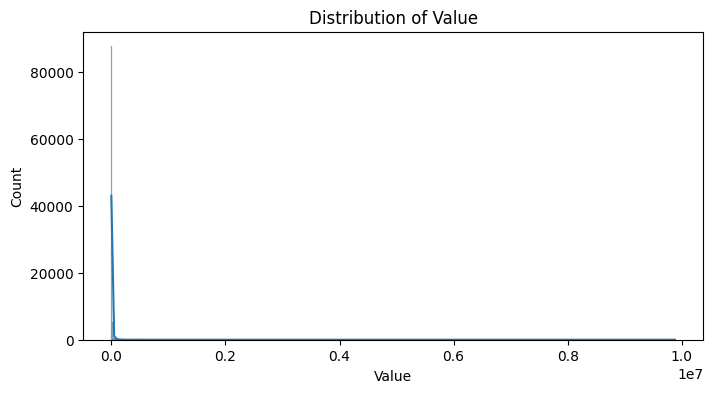

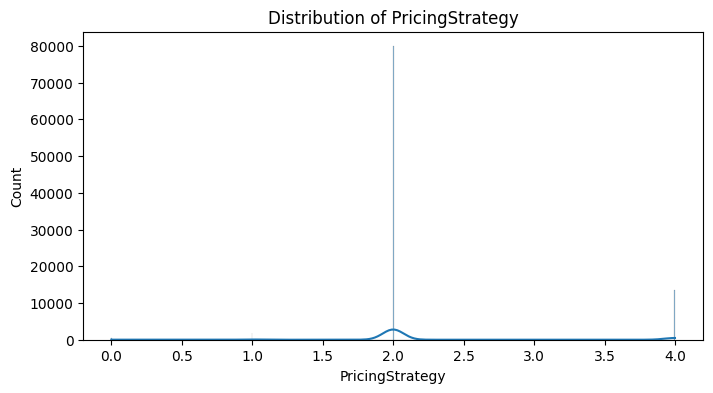

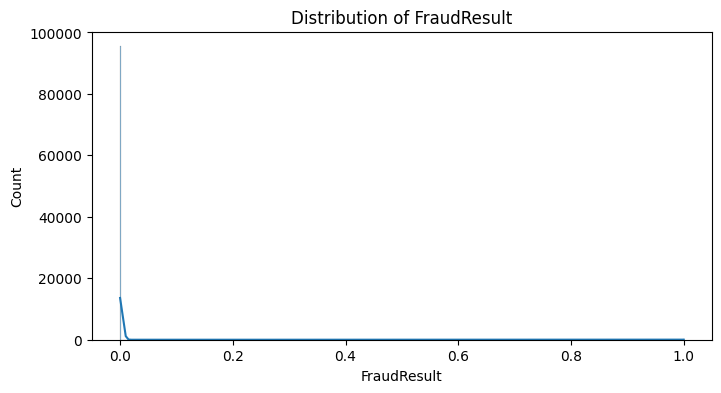

In [5]:
num_cols = ["Amount", "Value", "PricingStrategy", "FraudResult"]

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

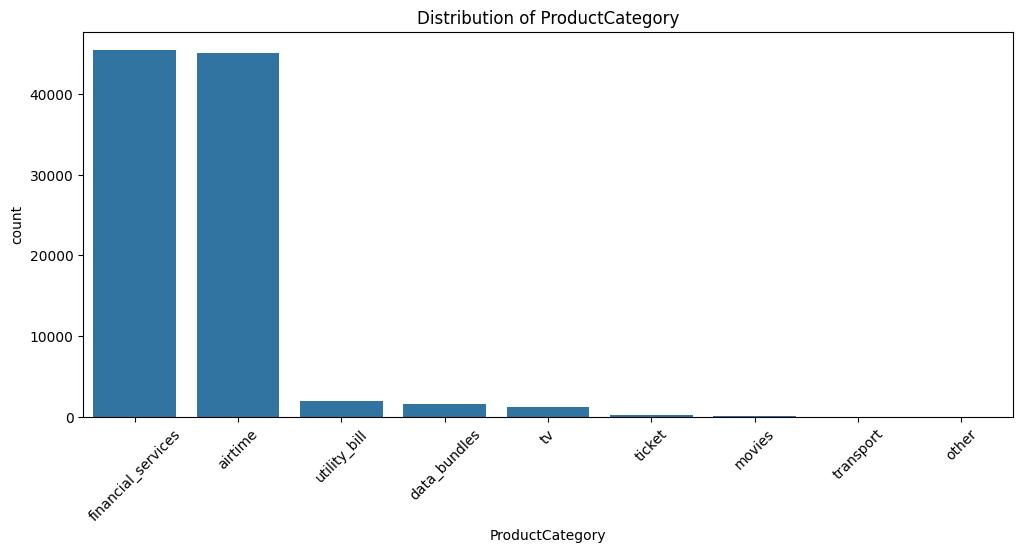

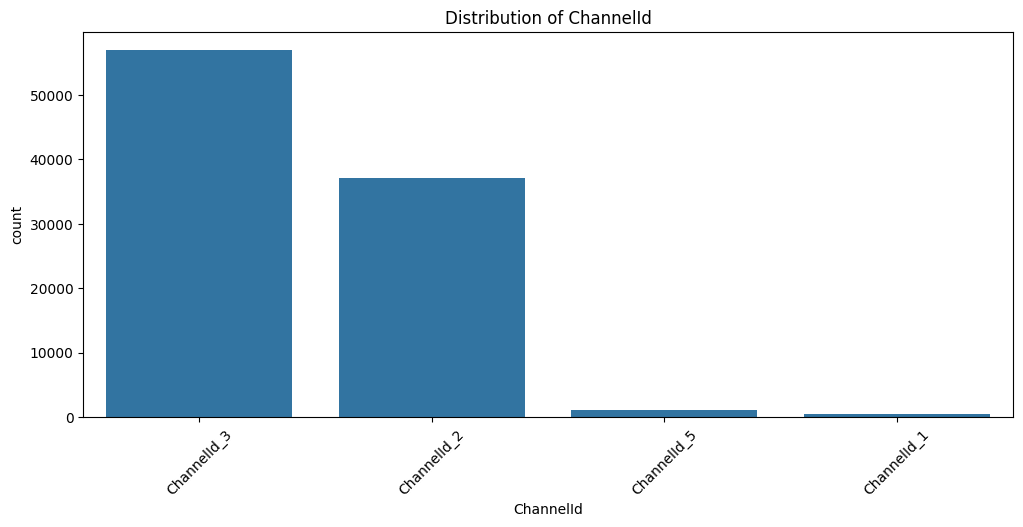

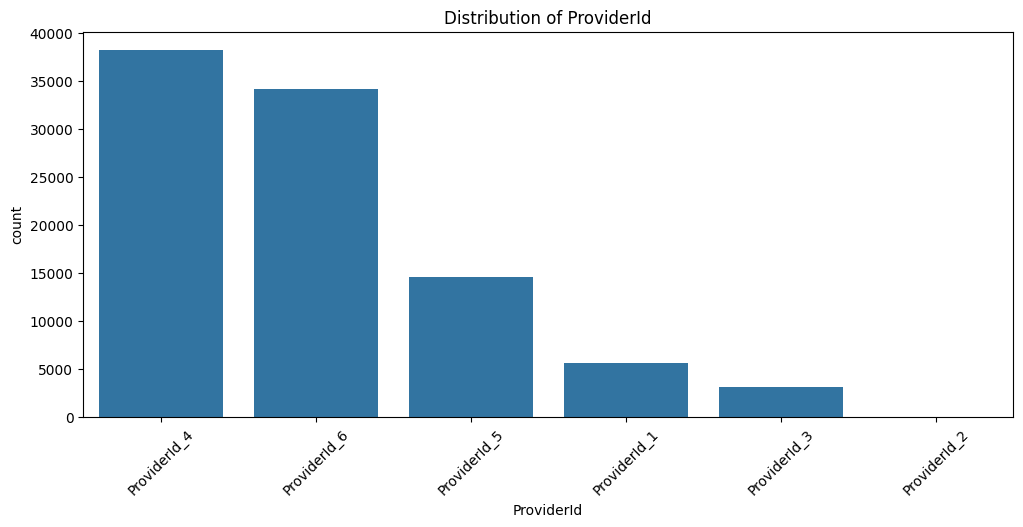

In [6]:
cat_cols = [
    "ProductCategory",
    "ChannelId",
    "ProviderId"
]

for col in cat_cols:
    plt.figure(figsize=(12,5))
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()

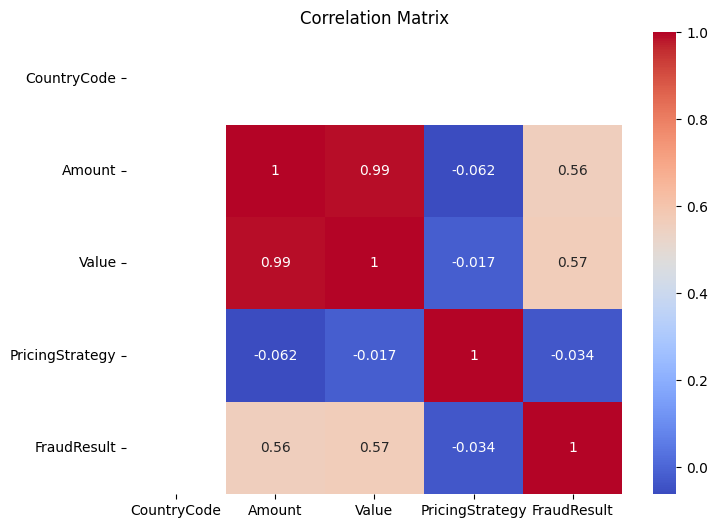

In [7]:
corr = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

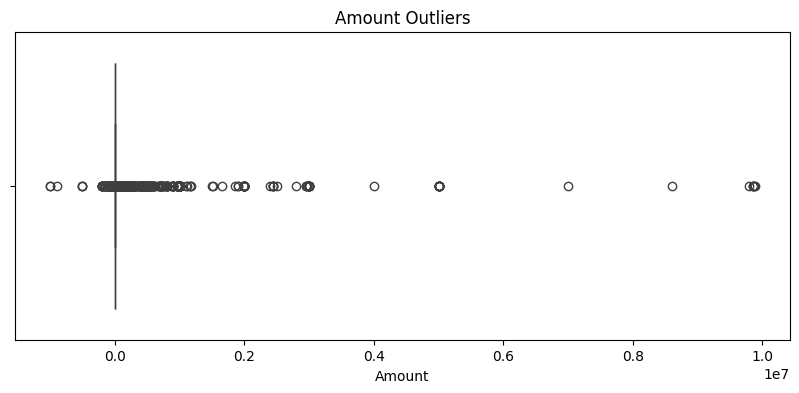

In [8]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["Amount"])
plt.title("Amount Outliers")
plt.show()

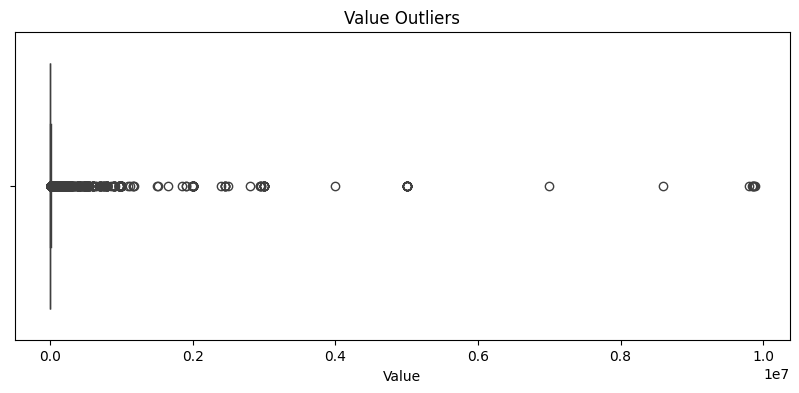

In [9]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["Value"])
plt.title("Value Outliers")
plt.show()

# EDA Conclusion

The dataset is generally clean, with no missing values and consistent feature formatting. However, several numerical variables exhibit strong skewness and significant outliers. Customer behavior appears concentrated in a small number of product categories, channels, and providers. These findings suggest that feature engineering, scaling, customer-level aggregation, and behavioral segmentation will be critical for building an effective credit risk model.


# Key Insights

1. The dataset contains 95,662 transactions and 16 features, providing a strong foundation for credit risk modeling.

2. No missing values were detected across any feature, eliminating the need for missing-value imputation during preprocessing.

3. Transaction Amount and Value are highly right-skewed and contain numerous extreme outliers. Most transactions are relatively small, while a small number of transactions have exceptionally large values.

4. ProductCategory is heavily dominated by financial_services and airtime transactions. Similarly, ChannelId_3 and ProviderId_4 account for the majority of transaction activity, indicating concentrated customer behavior patterns.

5. Amount and Value exhibit an extremely strong positive correlation (0.99), suggesting that they contain similar information and may introduce redundancy during model training.

6. PricingStrategy is overwhelmingly dominated by category 2, indicating limited variability in pricing strategies across transactions.

7. FraudResult is highly imbalanced, with fraudulent transactions representing only a very small fraction of all observations. This imbalance should be considered during model development and evaluation.

8. CountryCode contains only a single value (256) across all transactions and is unlikely to provide meaningful predictive information.
